#Lab2: Text Pre-processing and Regular Expressions
#Mohammed Moayed AlQurini - 2240007325 - 7MA2

 In this lab, you will learn essential techniques for preparing and cleaning text data using various pre-processing steps. Additionally, you will gain hands-on experience with regular expressions, a powerful tool for pattern matching and text manipulation in natural language processing (NLP) tasks.

_____________________________________________________________________________________________

## Regular Expressions

Regular expressions (regex) are extremely useful in extracting information from any text by searching for one or more matches of a specific search pattern

https://www.regexpal.com/

#### Regular Expressions use cases

- Data pre-processing
- Pattern matching
- Text feature Engineering
- Web scraping
- Data validation
- Data extraction

An example use case is extracting all hashtags from a tweet, or getting email addresses or phone numbers from large unstructured text content.

## Regular Expressions with Python

Python provides a convenient built-in module for managing regular expressions:

> import re

We can import it as we import any other Python library.

### Important symbols in Regular Expression

Let’s start with the basic regular expression characters and some examples:

- (^) : Matches the expression to its right, at the start of a string before it finds a line break.
- ($) : Matches the expression to its left, at the end of a string before it finds a line break.
- (.) : Matches any character except newline.
- (a) : Matches exactly one character.
- (ab) : Matches the string ab.

----------------------------------------------------------------------------
Quantifiers:

- (a|b) : Matches expression a or b. If a is matched first, b is not checked;
- (+) : Matches the expression to its left 1 or more times;
- (*) : Matches the expression to its left 0 or more times;
- (?) : Matches the expression to its left 0 or 1 times.
----------------------------------------------------------------------------
Character Classes:

- \w : Matches alphanumeric characters, that is a-z, A-Z, 0–9, and underscore(_);
- \W : Matches non-alphanumeric characters, that is except a-z, A-Z, 0–9, and _;
- \d : Matches digits, from 0–9;
- \D : Matches any non-digits;
- \s : Matches whitespace characters, which also include the \t, \n, \r, and space characters;
- \S : Matches non-whitespace characters.
- \n : Matches a newline character;
- \t : Matches a tab character;
- \b : Matches the word boundary (or empty string) at the start and end of a word;
- \B : Matches where \b does not, that is non-word boundary.

----------------------------------------------------------------------------
Sets:

- [abc] : Matches either a, b, or c. It does not match abc;
- [a-z] : Matches any alphabet from a to z;
- [A-Z] : Matches any alphabets in capital from A to Z;
- [a\-p] : Matches a, -, or p. It matches - because \ escapes it;
- [-z] : Matches - or z;
- [a-z0–9] : Matches characters from a to z or from 0 to 9.
- [(+*)] : Special characters become literal inside a set, so this matches (, +, *, or );
- [^ab5] : Adding ^ excludes any character in the set. Here, it matches characters that are not a, b, or 5;
----------------------------------------------------------------------------


### Regular Expression functions



#### search

Search for pattern occurrences in a string using the search function of the **re module**. This function returns a match object, containing the matched substring (or None, if it doesn’t exist) and its position inside the original string.

In [57]:
import re

text = 'I am enjoying the NLP course.'

print(re.search(r"I", text)) #r is maning i will start regular
print(re.search(r"se.$", text)) #$ look form the end
print(re.search(r"am", text))
print(re.search(r"m", text))
print(re.search(r"AI", text))

<re.Match object; span=(0, 1), match='I'>
<re.Match object; span=(26, 29), match='se.'>
<re.Match object; span=(2, 4), match='am'>
<re.Match object; span=(3, 4), match='m'>
None


In [58]:
match = re.search((r"I"),text)
print(match.span())
print(match.start())
print(match.end())
print("The matched pattern is: ",text[match.start():match.end()]) #index from text

(0, 1)
0
1
The matched pattern is:  I


#### match

The match function is similar to search, but it only tries to match the pattern at the beginning of the target string.

In [59]:
import re

text = 'I am enjoying the NLP course.'

print(re.search(r"I.*", text)) #globel
print(re.match(r"I.*", text)) #local >> see the start word

print(re.search(r"enjoying.*", text))
print(re.match(r"enjoying.*", text))

<re.Match object; span=(0, 29), match='I am enjoying the NLP course.'>
<re.Match object; span=(0, 29), match='I am enjoying the NLP course.'>
<re.Match object; span=(5, 29), match='enjoying the NLP course.'>
None


In [60]:
import re

text = '1999 was the year I was born.'

print(re.search(r"[a-zA-Z]+", text))
print(re.match(r"[a-zA-Z]+", text))

<re.Match object; span=(5, 8), match='was'>
None


Search does a global search, whereas match does a local search!

**Match** is often used when you need to check if the string starts with a specific pattern.


**Search** is used when you want to find a pattern anywhere within the string.

#### findall

The findall function looks for all the pattern matches in the target string (whereas search and match look only for the first occurrence). The former returns a list, and the latter returns an iterator.

In [61]:
import re

text1 = "a 1 b 2 c 3"
text2 = "a1 b2 c 3"
text3 = "a 1 b 222 c 3"

print(re.findall(r"\d+", text1)) #match any letter or digit
print(re.findall(r"\d+", text2))
print(re.findall(r"\d+", text3))

['1', '2', '3']
['1', '2', '3']
['1', '222', '3']


#### sub

The sub is a function that finds patterns in the target string and substitute them with another string.

flags=re.I --> non-case-sensitive

count = specify number of matches you want to replace

In [62]:
import re

text = 'I am enjoying the Math course.'

print(re.sub(r"Math", "NLP", text,1,flags=re.I)) #flags=re.I >> not mater if M or m
                                                 # 1 >> number of word i need it to change

I am enjoying the NLP course.


C:\Users\moham\AppData\Local\Temp\ipykernel_24276\3039230366.py:5: DeprecationWarning: 'count' is passed as positional argument
  print(re.sub(r"Math", "NLP", text,1,flags=re.I)) #flags=re.I >> not mater if M or m


#### compile

The compile function compiles a regular expression into a regular expression object, which allows for caching and faster pattern matching.

In [63]:
import re

text = "This year is 2021"
pattern = re.compile(r"\d+")

print(pattern.sub("2022", text))

This year is 2022


#### split

The split function is similar to the Python split function, but splits according to regular expression patterns.

In [64]:
import re

text = "a 1 b 2 c 3"

print(re.split(r"\d+", text))

['a ', ' b ', ' c ', '']


__________________________________________________________________________

## Text pre-processing steps


Text preprocessing involves transforming text into a clean and consistent format that can then be fed into a model for further analysis and learning. Raw text data might contain unwanted or unimportant text due to which our results might not give efficient accuracy, and might make it hard to understand and analyze.

**The various text preprocessing steps are:**

1. Tokenization.
2. Lower casing.
3. Stop words removal.
4. Stemming.
5. Lemmatization.

Before implementing the pre-processing, let us understand the concept first.

### Tokenization

Tokenization is used in NLP to split paragraphs and sentences into smaller units that can be more easily assigned meaning.

The first step of the NLP process is gathering the data (a sentence) and breaking it into understandable parts (words).

- **Sentance Tokenization**

In [65]:
# One-time setup: download the NLTK data files needed by this notebook
# (punkt/punkt_tab for sent_tokenize & word_tokenize, stopwords, wordnet for the lemmatizer)
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # required by newer NLTK versions (3.8.2+)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [66]:
import nltk

text = "I'm enjoying the NLP course! I am also learning new concepts."

print(nltk.sent_tokenize(text)) #base on . >> which is the end of sentencce

["I'm enjoying the NLP course!", 'I am also learning new concepts.']


- **Word Tokenzitaion**

In [67]:
text = "I'm enjoying the NLP course!"
text.split()

["I'm", 'enjoying', 'the', 'NLP', 'course!']

In [68]:
import nltk

text = "I'm enjoying the NLP course!"

print(nltk.word_tokenize(text))

['I', "'m", 'enjoying', 'the', 'NLP', 'course', '!']


In [69]:
#!pip install -U spacy
# !python -m spacy download en_core_web_sm

In [70]:
import spacy
nlp = spacy.load('en_core_web_sm')

doc = nlp("I'm enjoying the NLP course!")

for token in doc:
    print(token)

I
'm
enjoying
the
NLP
course
!


In [71]:
text = "A 5km NYC cab ride costs $10.30"
doc = nlp("A 5km NYC cab ride costs $10.30")
print('nltk', nltk.word_tokenize(text))

print('##############################')
for token in doc:
    print(token)

nltk ['A', '5km', 'NYC', 'cab', 'ride', 'costs', '$', '10.30']
##############################
A
5
km
NYC
cab
ride
costs
$
10.30


### Lower Casting

Converting a word to lower case (NLP -> nlp). Words like Book and book mean the same but when not converted to the lower case those two are represented as two different words in the vector space model (resulting in more dimensions).

In [72]:
text = "I'm enjoying the NLP course!"
text = text.lower()
text

"i'm enjoying the nlp course!"

### Stemming

Stemming is basically removing the suffix from a word and reduce it to its root word. For example: “Flying” is a word and its suffix is “ing”, if we remove “ing” from “Flying” then we will get base word or root word which is “Fly”. We uses these suffix to create a new word from original stem word.

https://www.nltk.org/howto/stem.html

#### What is PorterStemmer?

It is one of the most popular stemming methods proposed in 1980. It is based on the idea that the suffixes in the English language are made up of a combination of smaller and simpler suffixes. This stemmer is known for its speed and simplicity. The main applications of Porter Stemmer include data mining and Information retrieval. However, its applications are only limited to English words. Also, the group of stems is mapped on to the same stem and the output stem is not necessarily a meaningful word. The algorithms are fairly lengthy in nature and are known to be the oldest stemmer.

> Advantage: It produces the best output as compared to other stemmers and it has less error rate.

> Limitation:  Morphological variants produced are not always real words.

In [73]:
import nltk
from nltk.stem import PorterStemmer

ps = PorterStemmer()

words = ['run','runner','running','ran','runs','easily','fairly']

for word in words:
    print(word + ' --> ' + ps.stem(word))

run --> run
runner --> runner
running --> run
ran --> ran
runs --> run
easily --> easili
fairly --> fairli


#### What is SnowballStemmer?

It is a stemming algorithm which is also known as the Porter2 stemming algorithm as it is a better version of the Porter Stemmer since some issues of it were fixed in this stemmer.

> Advantage: It is slightly faster computation time than porter, with a reasonably large community around it.

In [74]:
import nltk
from nltk.stem.snowball import SnowballStemmer

sn = SnowballStemmer(language='english')

words = ['run','runner','running','ran','runs','easily','fairly']

for word in words:
    print(word+' --> '+sn.stem(word))

run --> run
runner --> runner
running --> run
ran --> ran
runs --> run
easily --> easili
fairly --> fair


#### Comparing between porter and snowball

In [75]:
words = ['generous','generation','generously','generate']

for word in words:
    print(word+' --> '+ps.stem(word))
    print(word+' --> '+sn.stem(word))
    print('---------------------------------------')

generous --> gener
generous --> generous
---------------------------------------
generation --> gener
generation --> generat
---------------------------------------
generously --> gener
generously --> generous
---------------------------------------
generate --> gener
generate --> generat
---------------------------------------


**Note**: Spacy does not provide stemming

### Lemmatization

Lemmatization is the process of grouping together the different inflected forms of a word so they can be analyzed as a single item. Lemmatization is similar to stemming but it brings context to the words. So it links words with similar meanings to one word.

> One major difference with stemming is that lemmatize takes a part of speech parameter, “pos” If not supplied, the default is “noun.”

In [76]:
import nltk
from nltk.stem import WordNetLemmatizer

text = 'I am enjoying with AI courses. I am taking NLP course.'
lemmatizer = WordNetLemmatizer()

for word in nltk.word_tokenize(text):
    print(f"{word}: ", lemmatizer.lemmatize(word))

I:  I
am:  am
enjoying:  enjoying
with:  with
AI:  AI
courses:  course
.:  .
I:  I
am:  am
taking:  taking
NLP:  NLP
course:  course
.:  .


You may go through Spacy's lemmatizer: https://spacy.io/api/lemmatizer

### ٍStop Words Removal

The words which are generally filtered out before processing a natural language are called stop words. These are actually the most common words in any language (like articles, prepositions, pronouns, conjunctions, etc) and does not add much information to the text. Examples of a few stop words in English are “the”, “a”, “an”, “so”, “what”.

#### Why do we need to remove stopwords?

By removing these words, we remove the low-level information from our text in order to give more focus to the important information. In order words, we can say that the removal of such words does not show any negative consequences on the model we train for our task.

- reduces the dataset size
- reduces the training time

#### Do we always remove stopwords? **NO!**

We do not always remove the stop words. The removal of stop words is highly dependent on the task we are performing and the goal we want to achieve. For example, if we are training a model that can perform the sentiment analysis task, we might not remove the stop words.

Movie review: “The movie was not good at all.”

Text after removal of stop words: “movie good”

In [77]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [78]:
print(nlp.Defaults.stop_words)


{'could', 'nothing', 'show', 'here', 'hundred', 'whither', 'nevertheless', 'all', 'over', 'one', 'whether', 'onto', 'someone', 'do', 'the', 'twenty', 'at', 'such', 'alone', 'they', 'yet', 'almost', 'out', 'everyone', 'a', 'becoming', 'every', 'might', 'once', 'among', 'per', 'btw', 'if', 'though', 'from', 'she', 'thereafter', 'under', 'n’t', 'whereby', 'can', 'noone', 'otherwise', 'else', '’s', "'d", "'ve", 'nor', 'everything', 'something', 'us', 'my', 'we', 'rather', 'seem', 'very', 'empty', 'thereupon', 'further', 'whereupon', 'this', 'then', 'meanwhile', 'regarding', 'ours', 'part', 'when', 'whence', 'other', 'down', 'whatever', '’d', 'put', 'top', "'s", 'made', 'wherein', 'there', 'must', 'thru', 'what', 'seemed', 'hereby', 'did', 'mine', 'say', 'into', 'already', 'themselves', 'just', 'none', 'via', 'whoever', 'back', 'you', 'full', 'our', 'became', 'how', 'upon', 'besides', 'am', 'eleven', 'six', 'without', 'above', '‘re', 'should', 'together', 'many', 'whole', 'its', 'your', 'si

In [79]:
print(nlp.vocab['myself'].is_stop)
print(nlp.vocab['mystery'].is_stop)

True
False


In [80]:
nlp.Defaults.stop_words.add('btw')
print (nlp.vocab['btw'].is_stop)

True


In [81]:
nlp.Defaults.stop_words.discard('beyond')
nlp.vocab['beyond'].is_stop = False

In [82]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [83]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
print(len(stop_words))
stop_words

198


{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

_________________________________________________________________________________________________________

# Text pre-processing Example

To make you understand better about the need of text pre-processing. We will do a small project. In this project, I need to find how many hashtags and the top 10 hashtags used in the dataset.

The dataset is about people tweets about apple company in the twitter. You can find the dataset here: https://www.kaggle.com/datasets/seriousran/appletwittersentimenttexts

Output labels:

- -1: negative
- 0: neutral
- 1: positive


---
# Task#1 Solution: Hashtag Extraction & Analysis (Apple Twitter Dataset)

**Goal:** Apply text pre-processing and regular expressions to the Apple Twitter sentiment
dataset in order to:
1. Determine the **total number of hashtags** in the dataset.
2. Identify the **top 10 most frequently used hashtags**.

Dataset: `apple-twitter-sentiment-texts.csv` (place it in the same folder as this notebook).

In [84]:
import pandas as pd
import re
from collections import Counter

# encoding='utf-8-sig' removes the BOM character at the start of the first column name
df = pd.read_csv(r'C:\Users\moham\Downloads\archive\apple-twitter-sentiment-texts.csv', encoding='utf-8-sig')

print(df.shape)
print(df.columns.tolist())
df.head()

(1630, 2)
['text', 'sentiment']


,text,sentiment
0,Wow. Yall needa step it up @Apple RT @heynyla:...,-1
1,What Happened To Apple Inc? http://t.co/FJEX...,0
2,Thank u @apple I can now compile all of the pi...,1
3,The oddly uplifting story of the Apple co-foun...,0
4,@apple can i exchange my iphone for a differen...,0


### Step 1: Extract all hashtags using a regular expression

In [85]:
# A hashtag starts with '#' followed by one or more word characters (letters/digits/underscore)
hashtag_pattern = r'#\w+'

all_hashtags = []
for tweet in df['text'].astype(str):
    all_hashtags.extend(re.findall(hashtag_pattern, tweet))

# Normalize case so that #Apple, #APPLE and #apple are counted as the same hashtag
all_hashtags_normalized = [tag.lower() for tag in all_hashtags]

print("Extracted", len(all_hashtags), "hashtag occurrences (raw).")
print("First 10 examples:", all_hashtags[:10])

Extracted 1616 hashtag occurrences (raw).
First 10 examples: ['#Note4', '#aapl', '#apple', '#aapl', '#aapl', '#AAPL', '#iPhone6Plus', '#aapl', '#Apple', '#Skyworks']


### Step 2: Total number of hashtags

In [86]:
total_hashtags = len(all_hashtags_normalized)
unique_hashtags = len(set(all_hashtags_normalized))
tweets_with_hashtags = df['text'].astype(str).str.contains(hashtag_pattern, regex=True).sum()

print(f"Total number of hashtags in the dataset : {total_hashtags}")
print(f"Number of unique hashtags               : {unique_hashtags}")
print(f"Tweets containing at least one hashtag  : {tweets_with_hashtags} out of {len(df)}")

Total number of hashtags in the dataset : 1616
Number of unique hashtags               : 555
Tweets containing at least one hashtag  : 783 out of 1630


### Step 3: Top 10 most frequently used hashtags

In [87]:
hashtag_counts = Counter(all_hashtags_normalized)
top_10 = hashtag_counts.most_common(10)

print("Top 10 hashtags:")
for i, (tag, count) in enumerate(top_10, start=1):
    print(f"{i:>2}. {tag:<15} -> {count} times")

Top 10 hashtags:
 1. #aapl           -> 400 times
 2. #apple          -> 162 times
 3. #iphone         -> 38 times
 4. #december       -> 37 times
 5. #iphone6        -> 29 times
 6. #stocks         -> 15 times
 7. #ipad           -> 14 times
 8. #iphone6plus    -> 13 times
 9. #iphone6s       -> 13 times
10. #tech           -> 12 times


### Step 4 (optional): Visualize the top 10 hashtags

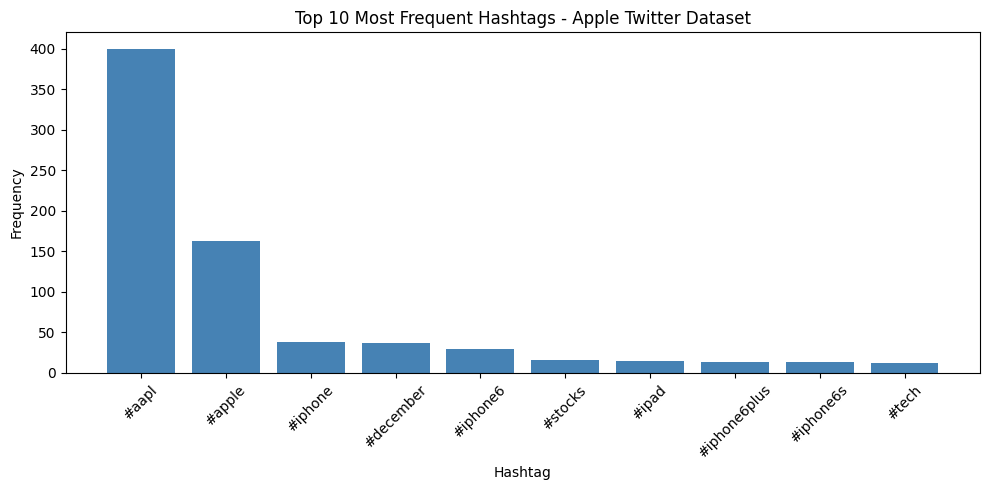

In [88]:
import matplotlib.pyplot as plt

tags, counts = zip(*top_10)

plt.figure(figsize=(10, 5))
plt.bar(tags, counts, color='steelblue')
plt.title('Top 10 Most Frequent Hashtags - Apple Twitter Dataset')
plt.xlabel('Hashtag')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusion

Running the cells above on `apple-twitter-sentiment-texts.csv` (1,630 tweets) gives:

- **Total hashtags found:** 1,616
- **Unique hashtags:** 555
- **Tweets containing at least one hashtag:** 783 out of 1,630

**Top 10 hashtags (case-normalized):**

| Rank | Hashtag | Count |
|---|---|---|
| 1 | #aapl | 400 |
| 2 | #apple | 162 |
| 3 | #iphone | 38 |
| 4 | #december | 37 |
| 5 | #iphone6 | 29 |
| 6 | #stocks | 15 |
| 7 | #ipad | 14 |
| 8 | #iphone6plus | 13 |
| 9 | #iphone6s | 13 |
| 10 | #tech | 12 |

`#AAPL`/`#aapl` (Apple's stock ticker) and `#Apple`/`#apple` dominate, which makes sense since
the dataset is built around tweets mentioning the company — a mix of stock/finance chatter and
product discussion (iPhone, iPad).

---
## What I Learned From This Lab

**Regular expressions**
- How to build patterns using anchors (`^`, `$`), quantifiers (`+`, `*`, `?`, `|`), character
  classes (`\w`, `\d`, `\s` and their negations), and sets (`[abc]`, `[a-z]`, `[^ab5]`).
- The difference between `re.search()` (finds a match anywhere in the string) and `re.match()`
  (only checks the very start of the string).
- `re.findall()` returns *all* matches as a list, which is exactly what was needed to pull every
  hashtag out of a tweet instead of just the first one.
- `re.sub()` and `re.compile()` for substitution and for reusing a pattern efficiently across many
  strings, and `re.split()` for splitting text on a pattern instead of a fixed character.

**Text pre-processing pipeline**
- **Tokenization** breaks text into words/sentences (`nltk.word_tokenize`, `nltk.sent_tokenize`,
  spaCy's tokenizer) as the first step before any other processing.
- **Lowercasing** avoids treating the same word as two different tokens (e.g. `NLP` vs `nlp`).
- **Stemming** (Porter vs Snowball) chops suffixes off quickly but can produce non-words; it's
  fast but crude.
- **Lemmatization** is slower but returns real dictionary words, using part-of-speech context.
- **Stop word removal** reduces noise and dataset size, but it is *not* always the right choice —
  for sentiment analysis, words like "not" can flip the meaning of a sentence entirely, so removing
  them can hurt more than it helps.

**Applying it to a real problem (Task#1)**
- Regex is genuinely practical for feature extraction from unstructured social media text — a
  single pattern (`#\w+`) was enough to pull every hashtag out of 1,630 real tweets.
- Case normalization matters for accurate counting: `#AAPL`, `#aapl`, and `#Aapl` are the same
  hashtag to a human but three different strings to a computer unless you lowercase them first.
  Normalizing changed the top count for `#aapl` from 203 (raw) to 400 (normalized) — nearly double.
- `collections.Counter` combined with `.most_common(n)` is a clean, efficient way to get frequency
  rankings instead of manually building and sorting a dictionary.
- The result itself was informative, not just a coding exercise: the dominance of `#aapl`/`#apple`
  shows this dataset is really a mix of **stock/finance discussion** (ticker symbol) and **product
  discussion** (iPhone, iPad), which is useful context to know before doing any sentiment modeling
  on this data later.